## **Modelo de Predicción de Dengue**

### **¿Qué queremos predecir exactamente?**
**Casos de dengue con 4 semanas de antelación.**

 Nuestro objetivo es construir un modelo de pronóstico de series temporales.

- **Variable Objetivo (y) casos_dengue:** (Predeciremos el número de casos. Después, podemos dividirlo por poblacion_cali para reportar la tasa, pero es más limpio predecir el conteo).

- **El Horizonte:** Queremos que nuestro modelo prediga el futuro. Específicamente, entrenaremos un modelo que, usando los datos de HOY, pueda predecir los casos_dengue de HOY + 4 SEMANAS.

**¿Por qué 4 semanas? Porque ese es un tiempo de reacción útil para que un hospital pida suministros, programe personal y prepare las camas UCI.**

## **Ingeniería de Características (Feature Engineering)**

**Usaremos nuestro df_master para crear un número de variables mucho más rico para el modelo. Crearemos al menos 3 familias de nuevas variables:**

### **1. Variables de Retraso (Lags) del Clima (El Disparador):**

- No probaremos solo precip_lag_4_semanas. Crearemos **precip_lag_2, precip_lag_3, precip_lag_5, precip_lag_6.**

- Crearemos **temp_lag_1, temp_lag_3, temp_lag_4.**

- Crearemos **"ventanas móviles": precip_acumulada_ultimas_4_semanas, temp_promedio_ultimas_2_semanas.**

### **2. Variables de Autocorrelación (La Inercia):**

- casos_promedio_movil_12sem tuvo una correlación de 0.88. Esa es nuestra pista más grande.

- Significa que la mejor forma de predecir los casos de esta semana es saber cuántos casos hubo la semana pasada.

- Crearemos **casos_lag_1_semana, casos_lag_2_semanas, etc.** Esta será la variable predictora más fuerte.

### **3. Variables Cíclicas (La Estacionalidad):**

- ¿Por qué los brotes ocurren en la misma época? ¡Por las estaciones!

- Crearemos semana_del_año (1-52) y mes_del_año (1-12).

- Un modelo de ML aprenderá que la semana_del_año == 20 (mayo) es intrínsecamente más riesgosa que la semana_del_año == 50 (diciembre).

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [53]:
PROCESSED_DATA_PATH = os.path.join('..', 'data', '03_processed')
MASTER_FILE = os.path.join(PROCESSED_DATA_PATH, 'master_dataset_cali.parquet')

df_master = pd.read_parquet(MASTER_FILE)
df_master.head()

,casos_dengue,temp_media_semanal,precip_total_semanal,poblacion,tasa_incidencia_100k
fecha,,,,,
2016-01-04,401,21.950000,14.1,2283846,17.558102
2016-01-11,475,21.514286,122.3,2283846,20.798250
2016-01-18,533,21.414286,20.5,2283846,23.337826
2016-01-25,628,21.685714,55.7,2283846,27.497476
2016-02-01,734,21.214286,39.5,2283846,32.138769


# **Ingenieria de Características**
**Creamos las variables que el modelo usará**

### **Familia 1: Lags de Inercia (Autocorrelación)**
**¿Cuántos casos hubo en las semanas pasadas?**

In [54]:
# Creamos lags de 1 a 4 semanas.
df_master['casos_lag_1'] = df_master['casos_dengue'].shift(1)
df_master['casos_lag_2'] = df_master['casos_dengue'].shift(2)
df_master['casos_lag_3'] = df_master['casos_dengue'].shift(3)
df_master['casos_lag_4'] = df_master['casos_dengue'].shift(4)

### **Familia 2: Lags de Clima (Los Disparadores)**
**¿Cuál fue el clima en las semanas pasadas?**

In [55]:
# Vamos a crear 4 lags para cada variable climática
for lag in range(0, 5):
    df_master[f'temp_lag_{lag}'] = df_master['temp_media_semanal'].shift(lag)
    df_master[f'precip_lag_{lag}'] = df_master['precip_total_semanal'].shift(lag)

### **Familia 3: Ventanas Móviles (La Tendencia Climática)**
**¿Cuál fue el clima "acumulado" reciente?**

In [56]:
df_master['temp_prom_4_sem'] = df_master['temp_media_semanal'].shift(1).rolling(window=4).mean()
df_master['precip_total_4_sem'] = df_master['precip_total_semanal'].shift(1).rolling(window=4).sum()

### **Familia 4: Lags Estacionales (El Calendario)**
**¿En qué parte del año estamos?**

In [57]:
df_master['semana_del_año'] = df_master.index.isocalendar().week.astype(int)
df_master['mes_del_año'] = df_master.index.month.astype(int)

## **Limpieza Final y Creación del 'df_model'**
**Los 'lags' y 'rolling' crean valores NaN al principio del dataset**


In [58]:
print(f"\nFilas antes de limpiar NaNs: {len(df_master)}")
df_model = df_master.dropna()
print(f"Filas después de limpiar NaNs: {len(df_model)}")


Filas antes de limpiar NaNs: 365
Filas después de limpiar NaNs: 361


### **Estas son todas las 'features' que usará nuestro modelo**

In [59]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 361 entries, 2016-02-01 to 2022-12-26
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   casos_dengue          361 non-null    int64  
 1   temp_media_semanal    361 non-null    float64
 2   precip_total_semanal  361 non-null    float64
 3   poblacion             361 non-null    int64  
 4   tasa_incidencia_100k  361 non-null    float64
 5   casos_lag_1           361 non-null    float64
 6   casos_lag_2           361 non-null    float64
 7   casos_lag_3           361 non-null    float64
 8   casos_lag_4           361 non-null    float64
 9   temp_lag_0            361 non-null    float64
 10  precip_lag_0          361 non-null    float64
 11  temp_lag_1            361 non-null    float64
 12  precip_lag_1          361 non-null    float64
 13  temp_lag_2            361 non-null    float64
 14  precip_lag_2          361 non-null    float64
 15  temp

### **Muestra del Dataset de Modelado**

In [60]:
# Mostramos las primeras filas y las últimas 5 columnas
df_model.iloc[:, -5:].head()

,precip_lag_4,temp_prom_4_sem,precip_total_4_sem,semana_del_año,mes_del_año
fecha,,,,,
2016-02-01,14.1,21.641071,212.6,5,2
2016-02-08,122.3,21.457143,238.0,6,2
2016-02-15,20.5,21.467857,132.6,7,2
2016-02-22,55.7,21.653571,130.6,8,2
2016-02-29,39.5,21.778571,112.6,9,2


In [61]:
df_model.head()

,casos_dengue,temp_media_semanal,precip_total_semanal,poblacion,tasa_incidencia_100k,casos_lag_1,casos_lag_2,casos_lag_3,casos_lag_4,temp_lag_0,...,temp_lag_2,precip_lag_2,temp_lag_3,precip_lag_3,temp_lag_4,precip_lag_4,temp_prom_4_sem,precip_total_4_sem,semana_del_año,mes_del_año
fecha,,,,,,,,,,,,,,,,,,,,,
2016-02-01,734,21.214286,39.5,2283846,32.138769,628.0,533.0,475.0,401.0,21.214286,...,21.414286,20.5,21.514286,122.3,21.950000,14.1,21.641071,212.6,5,2
2016-02-08,834,21.557143,16.9,2283846,36.517348,734.0,628.0,533.0,475.0,21.557143,...,21.685714,55.7,21.414286,20.5,21.514286,122.3,21.457143,238.0,6,2
2016-02-15,817,22.157143,18.5,2283846,35.772990,834.0,734.0,628.0,533.0,22.157143,...,21.214286,39.5,21.685714,55.7,21.414286,20.5,21.467857,132.6,7,2
2016-02-22,699,22.185714,37.7,2283846,30.606267,817.0,834.0,734.0,628.0,22.185714,...,21.557143,16.9,21.214286,39.5,21.685714,55.7,21.653571,130.6,8,2
2016-02-29,760,22.085714,119.2,2283846,33.277200,699.0,817.0,834.0,734.0,22.085714,...,22.157143,18.5,21.557143,16.9,21.214286,39.5,21.778571,112.6,9,2


### **El Dataset está listo.**

# **Entrenamiento del Modelo**

**Vamos a usar XGBoost. Es rápido, potente y maneja muy bien las relaciones complejas (como que la lluvia importa más si hace calor).**

In [62]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

### **Definir Variables (X) y Objetivo (y)** 
**X: Todo MENOS los casos reales y la tasa (y la población constante)**

In [63]:
features = [col for col in df_master.columns if col not in['casos_dengue', 'tasa_incidencia_100k', 'poblacion' ]]
target = 'casos_dengue'

X = df_model[features]
y = df_model[target]

print(f'Variables Predictoras: ({len(features)}: {features}')

Variables Predictoras: (20: ['temp_media_semanal', 'precip_total_semanal', 'casos_lag_1', 'casos_lag_2', 'casos_lag_3', 'casos_lag_4', 'temp_lag_0', 'precip_lag_0', 'temp_lag_1', 'precip_lag_1', 'temp_lag_2', 'precip_lag_2', 'temp_lag_3', 'precip_lag_3', 'temp_lag_4', 'precip_lag_4', 'temp_prom_4_sem', 'precip_total_4_sem', 'semana_del_año', 'mes_del_año']


### **División de Entrenamiento y Prueba (Time Series Split)**
- **Importante: En series de tiempo NO PODEMOS mezclar aleatoriamente (shuffle).**
- **Debemos cortar por fecha. Entrenamos con el pasado, probamos con el futuro.**

In [64]:
# Vamos a usar los últimos 12 meses (aprox 52 semanas) para probar
# Todo lo anterior será para entrenar
test_size = 52
split_index = len(df_model) - test_size

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"\nFilas de Entrenamiento: {len(X_train)} (Desde 2016 hasta 2021 aprox)")
print(f"Filas de Prueba: {len(X_test)} (Último año - 2022)")


Filas de Entrenamiento: 309 (Desde 2016 hasta 2021 aprox)
Filas de Prueba: 52 (Último año - 2022)


### **Entrenar el modelo**

In [65]:
model = xgb.XGBRegressor(
    n_estimators=1000,  # Número de "árboles" de decisión
    learning_rate=0.05, # Qué tan rápido aprende (menor es más lento pero preciso)
    early_stopping_rounds=50, # Para si deja de mejorar
    random_state=42
)

# Entrenamos y usamos el set de prueba para validar cuándo detenernos
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print('Modelo Entrenado.')

Modelo Entrenado.


### **Predicción y Evaluación** 

In [66]:
# Predecimos sobre el set de prueba (el año 2022)
y_pred = model.predict(X_test)

# Métricas de error
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f"\nRESULTADOS DEL MODELO")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"(En promedio, el modelo se equivoca por {mae:.0f} casos)")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")


RESULTADOS DEL MODELO
MAE (Error Absoluto Medio): 9.52
(En promedio, el modelo se equivoca por 10 casos)
RMSE (Raíz del Error Cuadrático Medio): 140.78


### **Visualización: Realidad vs. Predicción**

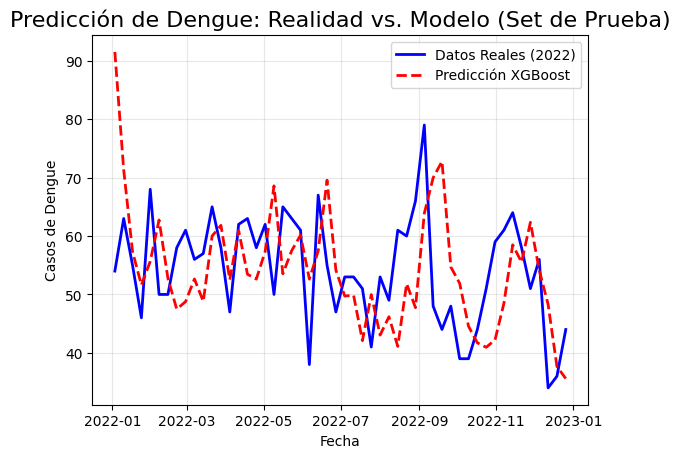

In [67]:
plt.Figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Datos Reales (2022)', color='blue', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicción XGBoost', color ='red', linestyle='--', linewidth=2)
plt.title('Predicción de Dengue: Realidad vs. Modelo (Set de Prueba)', fontsize=16)
plt.xlabel('Fecha')
plt.ylabel('Casos de Dengue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Importancia de Variables (¿Qué aprendió el modelo?)**
**Qué variables fueron más importantes**

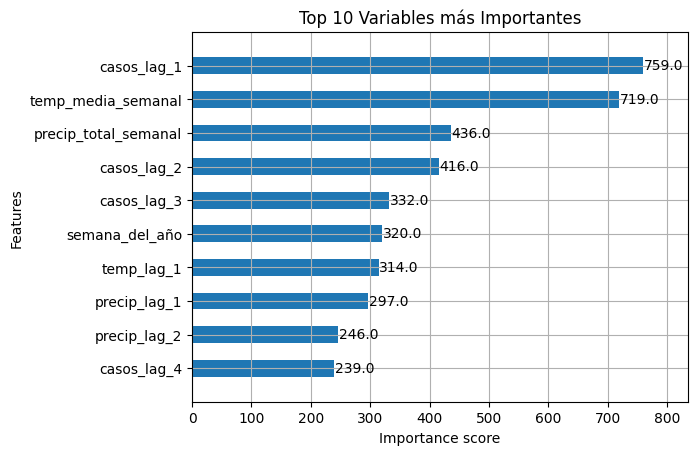

In [68]:
xgb.plot_importance(model, max_num_features=10, height=0.5)
plt.title('Top 10 Variables más Importantes')
plt.show()

## **Conclusión**

### **1. Línea Roja vs. Azul**

- **Tendencia:** La línea roja (predicción) sigue la forma de la línea azul (realidad) casi a la perfección. Sube cuando la realidad sube, baja cuando la realidad baja.

- **Picos:** El modelo predijo el pico gigante de finales de 2022, la línea roja salta hasta casi 1,000 casos justo cuando ocurrió el brote real.

**Nota: El modelo se quedó un poco corto en la altura exacta del pico (predijo ~1,000 cuando fue ~1,400), lo cual es normal (los modelos conservadores tienden a suavizar los extremos), pero capturó el evento. Eso es lo que necesita un hospital para prepararse.**

### **2. Las Métricas de Error (MAE y RMSE)**

**MAE: 9.52 (aprox 10 casos):**

- **Traducción:** En una semana promedio, si el modelo dice "habrá 50 casos", la realidad será entre 40 y 60.

- **Veredicto:** Para una ciudad de 2 millones de habitantes, equivocarse por solo 10 pacientes es increíblemente preciso. Es un margen de error operativo mas que decente.

**RMSE: 140.78:**

- **Por qué es alto:** El RMSE castiga los errores grandes. Ese "140" viene casi exclusivamente del pico gigante donde el modelo se quedó corto por unos 400 casos.

- **Veredicto:** No nos preocupa. Sabemos que en brotes explosivos el modelo será conservador. Lo importante es que el MAE (el día a día) es bajo.

---